In [2]:
# 데이터 처리 및 분석
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
import warnings

# 경로 설정
import os
import sys

# 시각화
import matplotlib.pyplot as plt
import seaborn as sns

# 출력 설정
warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

# 한글 폰트 설정
import platform

if platform.system() == "Windows":
    plt.rcParams["font.family"] = "Malgun Gothic"
elif platform.system() == "Darwin":
    plt.rcParams["font.family"] = "AppleGothic"
else:
    plt.rcParams["font.family"] = "NanumGothic"

plt.rcParams["axes.unicode_minus"] = False
plt.rcParams["figure.figsize"] = (12, 6)

# 시드 설정
np.random.seed(42)

print("-" * 60)
print("라이브러리 로드 완료")
print("한글 폰트 설정 완료!")
print("-" * 60)

------------------------------------------------------------
라이브러리 로드 완료
한글 폰트 설정 완료!
------------------------------------------------------------


In [3]:
# 현재 작업 디렉토리(notebooks)의 부모 디렉토리(root)를 경로에 추가
os.chdir(os.path.abspath(".."))
print(os.getcwd())

df = pd.read_csv("data/2025_Airbnb_NYC_listings.csv").drop(columns="Unnamed: 0")
df.head()

d:\Dev\airbnb_price_prediction


,id,source,name,description,neighborhood_overview,host_id,host_name,host_since,host_location,host_about,host_response_time,host_response_rate,host_acceptance_rate,host_is_superhost,host_neighbourhood,host_listings_count,host_total_listings_count,host_verifications,host_has_profile_pic,host_identity_verified,neighbourhood,neighbourhood_cleansed,neighbourhood_group_cleansed,latitude,longitude,property_type,room_type,accommodates,bathrooms,bathrooms_text,bedrooms,beds,amenities,price,minimum_nights,maximum_nights,minimum_minimum_nights,maximum_minimum_nights,minimum_maximum_nights,maximum_maximum_nights,minimum_nights_avg_ntm,maximum_nights_avg_ntm,calendar_updated,has_availability,availability_30,availability_60,availability_90,availability_365,calendar_last_scraped,number_of_reviews,number_of_reviews_ltm,number_of_reviews_l30d,availability_eoy,number_of_reviews_ly,estimated_occupancy_l365d,estimated_revenue_l365d,first_review,last_review,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
0,36121,city scrape,Lg Rm in Historic Prospect Heights,Cozy space share in the heart of a great neigh...,Full of tree-lined streets and beautiful brown...,62165,Michael,2009-12-11,"New York, NY",I’m an urban planner working for an internatio...,NaN,NaN,NaN,f,Prospect Heights,1.0,3.0,"['email', 'phone', 'work_email']",t,t,Neighborhood highlights,Prospect Heights,Brooklyn,40.673760,-73.966110,Private room in rental unit,Private room,1,1.0,1 shared bath,1.0,1.0,"[""Refrigerator"", ""Dishes and silverware"", ""Wif...",$200.00,90,365,90.0,90.0,365.0,365.0,90.0,365.0,NaN,t,27,57,87,362,2025-03-03,9,0,0,301,0,0,0.0,2010-12-11,2013-05-10,4.88,5.00,4.80,5.00,5.00,5.00,5.00,NaN,f,1,0,1,0,0.05
1,36647,city scrape,"1 Bedroom & your own Bathroom, Elevator Apartment",Private bedroom with your own bathroom in a 2 ...,"Manhattan, SE corner of 2nd Ave/ E. 110th street",157798,Irene,2010-07-04,"New York, NY",NaN,NaN,NaN,100%,f,East Harlem,1.0,1.0,"['email', 'phone']",t,t,Neighborhood highlights,East Harlem,Manhattan,40.792454,-73.940742,Private room in condo,Private room,2,1.0,1 private bath,1.0,1.0,"[""Oven"", ""Blender"", ""Luggage dropoff allowed"",...",$82.00,30,999,30.0,30.0,999.0,999.0,30.0,999.0,NaN,t,0,0,0,204,2025-03-03,102,0,0,143,0,0,0.0,2010-10-04,2023-12-09,4.77,4.82,4.76,4.88,4.90,4.38,4.71,NaN,f,1,0,1,0,0.58
2,38663,city scrape,Luxury Brownstone in Boerum Hill,"Beautiful, large home in great hipster neighbo...","diverse, lively, hip, cool: loaded with restau...",165789,Sarah,2010-07-13,"New York, NY",I am a lawyer and work as an executive at an a...,within a few hours,100%,40%,f,Boerum Hill,1.0,3.0,"['email', 'phone', 'work_email']",t,t,Neighborhood highlights,Boerum Hill,Brooklyn,40.684420,-73.980680,Private room in home,Private room,2,2.5,2.5 baths,5.0,5.0,"[""Portable fans"", ""Oven"", ""Baking sheet"", ""Fir...",$765.00,3,60,3.0,3.0,60.0,60.0,3.0,60.0,NaN,t,30,49,66,326,2025-03-02,43,0,0,267,0,0,0.0,2012-07-09,2023-08-30,4.70,4.83,4.52,4.88,4.88,4.86,4.62,OSE-STRREG-0001784,f,1,0,1,0,0.28
3,38833,city scrape,Spectacular West Harlem Garden Apt,This is a very large and unique space. An inc...,West Harlem is now packed with great restauran...,166532,Matthew,2010-07-14,"New York, NY",I have been a New Yorker for a long time\n and...,within an hour,100%,97%,t,Harlem,1.0,1.0,"['email', 'phone']",t,t,Neighborhood highlights,Harlem,Manhattan,40.818058,-73.946671,Entire home,Entire home/apt,2,1.0,1 bath,1.0,1.0,"[""Fire extinguisher"", ""Clothing storage: close...",$139.00,2,45,2.0,2.0,1125.0,1125.0,2.0,1125.0,NaN,t,7,18,25,25,2025-03-03,241,42,3,25,43,255,35445.0,2010-08-28,2025-02-21,4.85,4.87,4.50,4.96,4.96,4.79,4.82,OSE-STRREG-0000476,

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 22308 entries, 0 to 22307
Data columns (total 72 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   id                                            22308 non-null  int64  
 1   source                                        22308 non-null  str    
 2   name                                          22308 non-null  str    
 3   description                                   21903 non-null  str    
 4   neighborhood_overview                         12262 non-null  str    
 5   host_id                                       22308 non-null  int64  
 6   host_name                                     22288 non-null  str    
 7   host_since                                    22288 non-null  str    
 8   host_location                                 17025 non-null  str    
 9   host_about                                    13391 non-null  str    
 1

In [5]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
id,22308.0,NaN,NaN,NaN,594931827143523456.0,516864910912614336.0,6848.0,41372693.25,727563706116818176.0,1067266443718449536.0,1366912874990325504.0
source,22308,1,city scrape,22308,NaN,NaN,NaN,NaN,NaN,NaN,NaN
name,22308,21342,Wyndham Midtown 45 Resort | King Bed Hotel Room,14,NaN,NaN,NaN,NaN,NaN,NaN,NaN
description,21903,17854,Keep it simple at this peaceful and centrally-...,72,NaN,NaN,NaN,NaN,NaN,NaN,NaN
neighborhood_overview,12262,8232,This furnished property is located on the Uppe...,106,NaN,NaN,NaN,NaN,NaN,NaN,NaN
host_id,22308.0,NaN,NaN,NaN,216347621.868881,202510512.17774,1678.0,27181542.0,137358866.0,415840703.0,681436540.0
host_name,22288,5343,Blueground,1094,NaN,NaN,NaN,NaN,NaN,NaN,NaN
host_since,22288,4567,2016-12-16,1096,NaN,NaN,NaN,NaN,NaN,NaN,NaN
host_location,17025,421,"New York, NY",13441,NaN,NaN,NaN,NaN,NaN,NaN,NaN
host_about,13391,5804,"We’re Blueground, a global proptech company wi...",1094,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [6]:
# 1차 전처리 columns
drop_cols = ["source", "calendar_updated", "calendar_last_scraped"]

convert_tf_cols = [
    "host_is_superhost",
    "host_has_profile_pic",
    "host_identity_verified",
    "has_availability",
    "instant_bookable",
]

df["price"] = df["price"].str.replace("$", "").str.replace(",", "").astype("float")

df["host_since"] = pd.to_datetime(df["host_since"])


# 처리 함수
def convert_tf(df, cols):
    for col in cols:
        df[col] = df[col].map({"t": True, "f": False}).astype("boolean")

    return df


df_cleaned = convert_tf(df, convert_tf_cols)
df_cleaned = df_cleaned.drop(columns=drop_cols)

In [7]:
df_cleaned.shape

(22308, 69)

Successfully saved: docs/images/가격 히스토그램.png


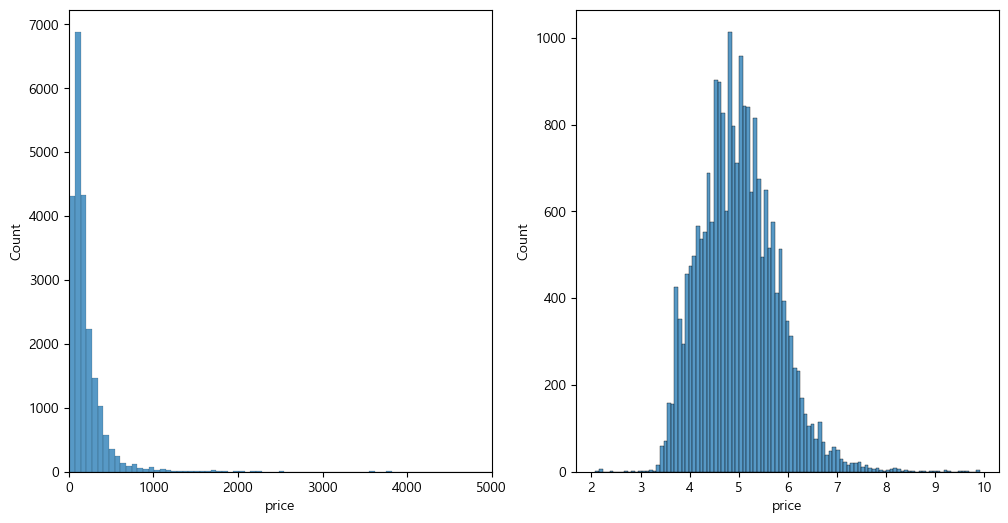

In [8]:
from src import utils

fig, axs = plt.subplots(1, 2)

sns.histplot(df_cleaned["price"], ax=axs[0])
axs[0].set_xlim(0, 5000)

log_price = np.log(df_cleaned["price"] + 1)
sns.histplot(log_price, ax=axs[1])

utils.save_image(fig, "가격 히스토그램")

정규성 검정 결과: 2.1864019793152053e-46


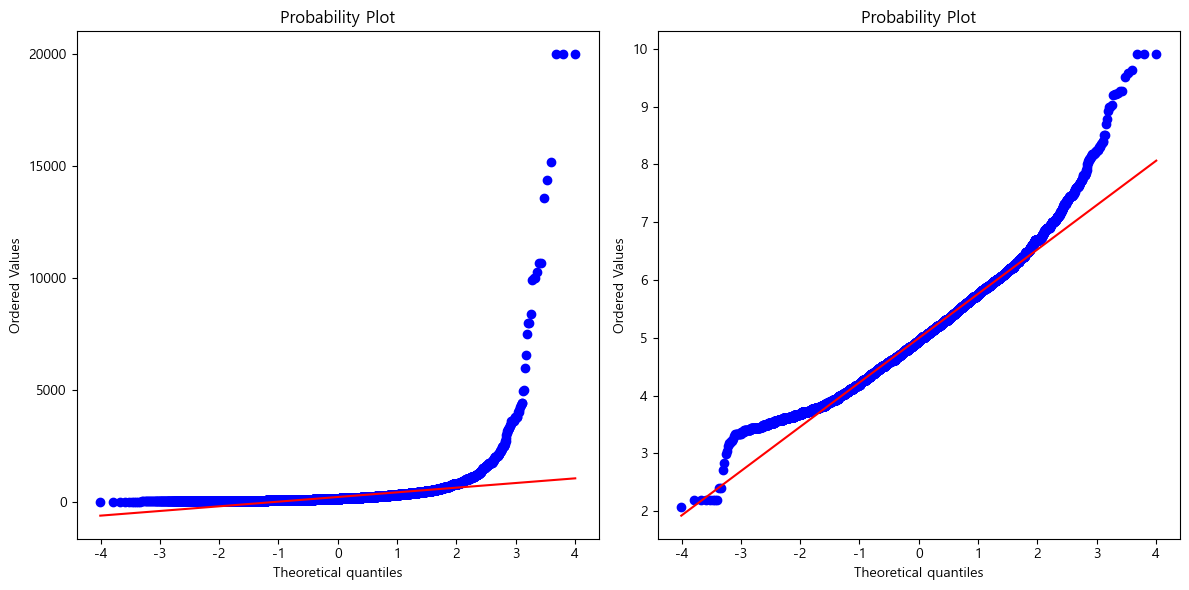

Successfully saved: docs/images/가격 QQ plot.png
왜도 :  0.5681430454641385
첨도 :  1.0437562006959409


In [9]:
from scipy.stats import shapiro, probplot

shapiro_stat, p_val = shapiro(log_price)
print("정규성 검정 결과:", p_val)

fig, axs = plt.subplots(1, 2)

probplot(df_cleaned["price"], dist="norm", plot=axs[0])
probplot(log_price, dist="norm", plot=axs[1])
plt.tight_layout()
plt.show()

utils.save_image(fig, "가격 QQ plot")

print("왜도 : ", log_price.skew())
print("첨도 : ", log_price.kurt())

In [10]:
df_cleaned["log_price"] = np.log(df_cleaned["price"] + 1)
df_cleaned.shape

(22308, 70)

# PJH

In [11]:
df_cleaned[["number_of_reviews"]]

,number_of_reviews
0,9
1,102
2,43
3,241
4,274
...,...
22303,0
22304,0
22305,0
22306,0


In [12]:
# 데이터 타입 확인
df_cleaned["number_of_reviews"].dtypes

dtype('int64')

In [13]:
# 평균, 최소/최대값, 중간값, 상/하위 25% 값
df_cleaned[["number_of_reviews"]].describe().round(2)

,number_of_reviews
count,22308.00
mean,34.35
std,76.78
min,0.00
25%,0.00
50%,5.00
75%,35.00
max,2749.00


- 평균 리뷰 수 34 뭔데? 신뢰성 없음
- 중앙값 5개 ㅋ
- 25% 까지도 0개, 50% 간신히 5개, 75% 35개 == 리뷰 수가 많은 순으로 봐야할 것 같은데?
- 최댓값 2749 심상찮음. : 거의 도시의 랜드마크급 숙소?

In [14]:
len(df_cleaned[df_cleaned["number_of_reviews"] == 0])

6798

In [15]:
# 결측치 확인
df_cleaned["review_scores_value"].isna().sum()

np.int64(6798)

In [16]:
df_cleaned[(df_cleaned["number_of_reviews"] > 800) & (df_cleaned["number_of_reviews"] < 1000)][["number_of_reviews"]]

,number_of_reviews
8122,876
9499,939
10773,999


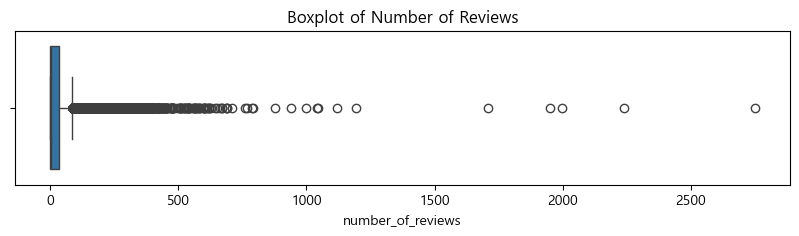

In [17]:
# 이상치 확인
plt.figure(figsize=(10, 2))
sns.boxplot(x=df_cleaned["number_of_reviews"])
plt.title("Boxplot of Number of Reviews")
plt.show()

- 리뷰 수 800 이상 부터 띄엄띄엄
### 이산형 범주화
- 리뷰 유무?
- super_host(>=500)/activate(35~500)/biginning(1~34)/non_activate(0)
- 1000이상을 1000으로 처리할지


In [18]:
# 필터링
review_filtered = df_cleaned[(df_cleaned["number_of_reviews"] > 0) & (df_cleaned["number_of_reviews"] < 35)].copy()

print(f"데이터 수: {len(review_filtered)}개")
review_filtered[["number_of_reviews"]].describe().round(2)

데이터 수: 9848개


,number_of_reviews
count,9848.00
mean,10.09
std,9.41
min,1.00
25%,2.00
50%,7.00
75%,16.00
max,34.00


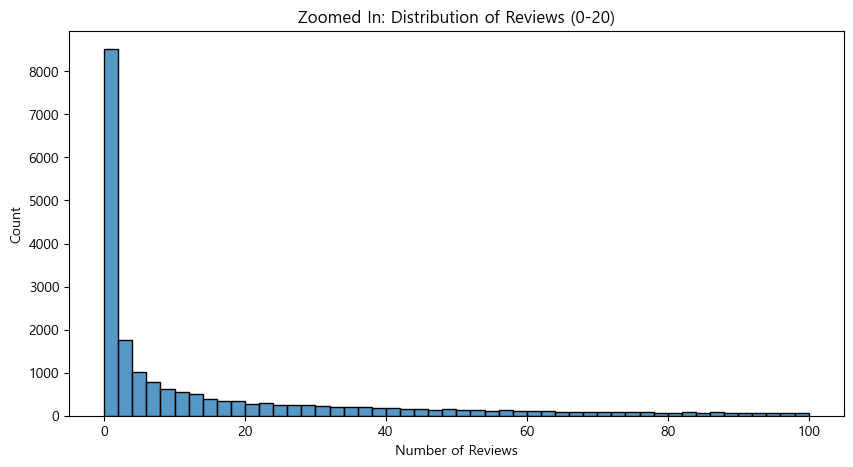

In [19]:
plt.figure(figsize=(10, 5))

sns.histplot(df_cleaned["number_of_reviews"], binrange=(0, 100), bins=50)  # 0부터 100까지(조절)
plt.title("Zoomed In: Distribution of Reviews (0-20)")
plt.xlabel("Number of Reviews")
plt.ylabel("Count")
plt.show()

In [20]:
# 0보다 큰 리뷰만
review_nonzero = df_cleaned[df_cleaned["number_of_reviews"] > 0]
(review_nonzero["number_of_reviews"] > 0).sum()

np.int64(15510)

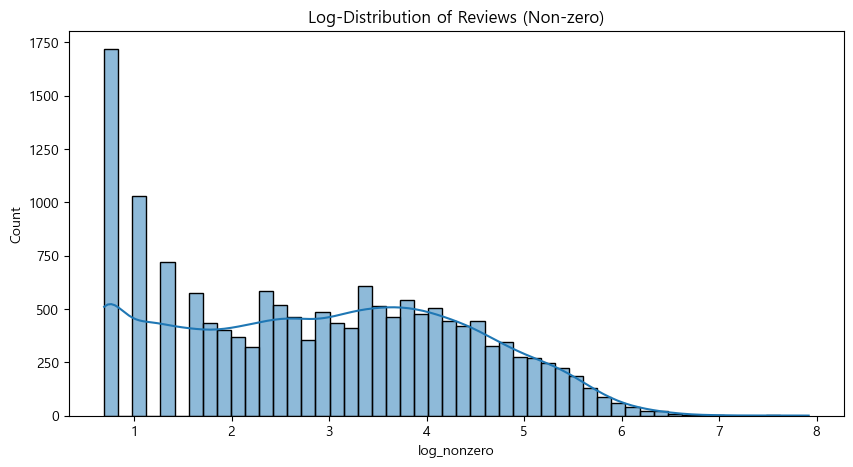

In [21]:
# 로그 변환
review_nonzero = df_cleaned[df_cleaned["number_of_reviews"] > 0].copy()  # .copy() 추가
review_nonzero["log_nonzero"] = np.log1p(review_nonzero["number_of_reviews"])

plt.figure(figsize=(10, 5))
sns.histplot(review_nonzero["log_nonzero"], bins=50, kde=True)
plt.title("Log-Distribution of Reviews (Non-zero)")
plt.show()

### 4개부터 우하향

In [22]:
q3 = df_cleaned["number_of_reviews"].quantile(0.75)

top_25_df_cleaned = df_cleaned[df_cleaned["number_of_reviews"] >= q3].copy()

print(f"상위 25% 리뷰 수: {q3}개")
print(f"데이터 개수: {len(top_25_df_cleaned)}개")
print(top_25_df_cleaned["number_of_reviews"].describe())

상위 25% 리뷰 수: 35.0개
데이터 개수: 5662개
count    5662.000000
mean      117.794772
std       116.932080
min        35.000000
25%        52.000000
50%        81.000000
75%       144.000000
max      2749.000000
Name: number_of_reviews, dtype: float64


In [23]:
# 상위 5% (슈퍼그룹)
super_reviews = df_cleaned["number_of_reviews"].quantile(0.95)


# 등급 함수 정의
def get_group(x, super_95, super_75):
    if x >= super_95:
        return "Super Group (Top 5%)"
    elif x >= super_75:
        return "Active Group (Top 25%)"
    else:
        return "Beginning Group"


# 데이터프레임에 그룹 적용
df_cleaned["review_group"] = df_cleaned["number_of_reviews"].apply(lambda x: get_group(x, super_reviews, q3))

# 슈퍼그룹만 별도로 추출
super_group_df_cleaned = df_cleaned[df_cleaned["review_group"] == "Super Group (Top 5%)"].copy()

print(f"슈퍼그룹 진입 기준 (리뷰 수): {super_reviews:.1f}개 이상")
print(f"슈퍼그룹 데이터 수: {len(super_group_df_cleaned)}개")

슈퍼그룹 진입 기준 (리뷰 수): 170.0개 이상
슈퍼그룹 데이터 수: 1117개


In [24]:
df_cleaned[["number_of_reviews", "review_group"]].head(15)

,number_of_reviews,review_group
0,9,Beginning Group
1,102,Active Group (Top 25%)
2,43,Active Group (Top 25%)
3,241,Super Group (Top 5%)
4,274,Super Group (Top 5%)
5,44,Active Group (Top 25%)
6,194,Super Group (Top 5%)
7,1,Beginning Group
8,251,Super Group (Top 5%)
9,398,Super Group (Top 5%)


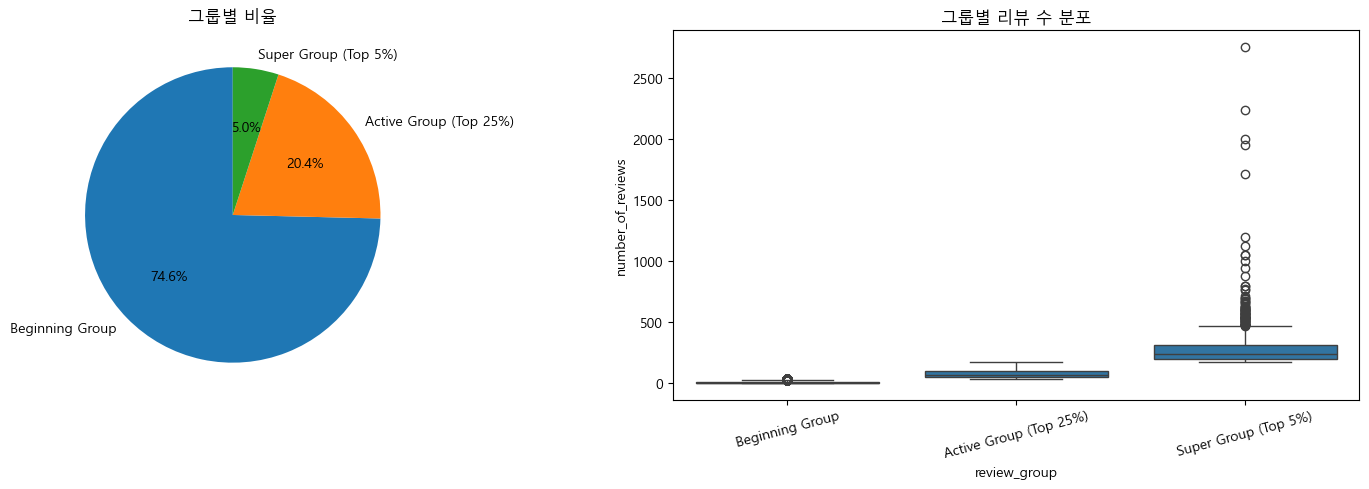

In [25]:
# 그룹별 비율 파이차트
rgroup_counts = df_cleaned["review_group"].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].pie(rgroup_counts, labels=rgroup_counts.index, autopct="%1.1f%%", startangle=90)
axes[0].set_title("그룹별 비율")

# 그룹별 리뷰 수 분포
sns.boxplot(data=df_cleaned, x="review_group", y="number_of_reviews", ax=axes[1])
axes[1].set_title("그룹별 리뷰 수 분포")
axes[1].tick_params(axis="x", rotation=15)

plt.tight_layout()
plt.show()

In [26]:
# 그룹별 비교
rgroup_summary = (
    df_cleaned.groupby("review_group")
    .agg(
        총_리뷰수=("number_of_reviews", "count"),
        평균_리뷰수=("number_of_reviews", "mean"),
        중앙값_리뷰수=("number_of_reviews", "median"),
    )
    .round(2)
)

print(rgroup_summary)

                        총_리뷰수  평균_리뷰수  중앙값_리뷰수
review_group                                  
Active Group (Top 25%)   4545   77.23     68.0
Beginning Group         16646    5.97      1.0
Super Group (Top 5%)     1117  282.83    238.0


-------------------------------------------
# reviews_per_month 월별 평균 리뷰 수

In [27]:
df_cleaned[["reviews_per_month"]]

,reviews_per_month
0,0.05
1,0.58
2,0.28
3,1.36
4,1.54
...,...
22303,NaN
22304,NaN
22305,NaN
22306,NaN


In [28]:
df_cleaned[["reviews_per_month"]].describe().round(4)

,reviews_per_month
count,15510.0000
mean,1.1600
std,2.2238
min,0.0100
25%,0.1800
50%,0.5000
75%,1.4900
max,117.9800


In [29]:
# 전체 15510개 중 결측치 6798개
df_cleaned["reviews_per_month"].isna().sum()

np.int64(6798)

1. 평균(1.16) 중앙값(0.5) : 평균을 끌어올리는 데이터가 있다.
2. 최솟값 0.01 최댓값 117.98 : 이상치 확인할 것 
3. 결측치 의미: 리뷰가 하나도 없는 숙소

In [30]:
# 결측치 -> 리뷰수 0으로
df_cleaned["reviews_per_month"] = df_cleaned["reviews_per_month"].fillna(0)

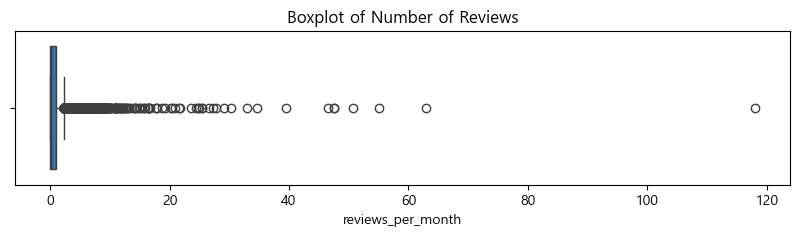

In [31]:
# 이상치 확인
plt.figure(figsize=(10, 2))
sns.boxplot(x=df_cleaned["reviews_per_month"])
plt.title("Boxplot of Number of Reviews")
plt.show()

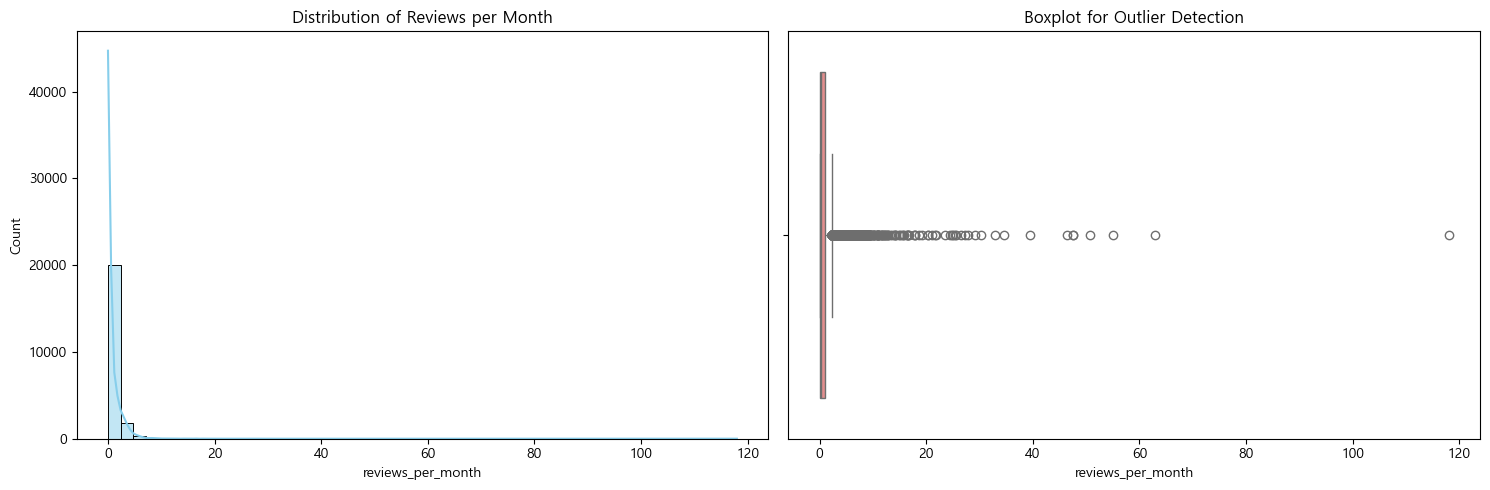

In [32]:
plt.figure(figsize=(15, 5))

# 1. 히스토그램 (치우침 확인)
plt.subplot(1, 2, 1)
sns.histplot(df_cleaned["reviews_per_month"], bins=50, kde=True, color="skyblue")
plt.title("Distribution of Reviews per Month")

# 2. 박스플롯 (이상치 시각화)
plt.subplot(1, 2, 2)
sns.boxplot(x=df_cleaned["reviews_per_month"], color="lightcoral")
plt.title("Boxplot for Outlier Detection")

plt.tight_layout()
plt.show()

# review_scores_rating 전반적인 평점

In [33]:
# 연속형
df_cleaned[["review_scores_rating"]]

,review_scores_rating
0,4.88
1,4.77
2,4.70
3,4.85
4,4.82
...,...
22303,NaN
22304,NaN
22305,NaN
22306,NaN


In [34]:
df_cleaned[["review_scores_rating"]].isna().sum()

review_scores_rating    6798
dtype: int64

In [35]:
# 결측치 -> 리뷰 수 0
df_cleaned["review_scores_rating"] = df_cleaned["review_scores_rating"].fillna(0)

In [36]:
# 평점 이상치 확인
df_cleaned[["review_scores_rating"]].describe().round(3)

,review_scores_rating
count,22308.000
mean,3.285
std,2.208
min,0.000
25%,0.000
50%,4.690
75%,4.920
max,5.000


- 전체의 25% 이상이 평점 0, 중앙값 갑자기 4.69 (평점이 0 아니면 4점대 이상) → 중간값이 거의 없음. 즉, 평가받은 숙소는 대부분 고평점 인 것(리뷰를 썼다는 사실 = 만족도 높음)
- 최솟값 0, 최댓값 5 : 최고점이 5점

#### 평점 0 처리 방법 선택
- 분석에서 제외: df_cleaned[df_cleaned['review_scores_rating'] > 0]
- 리뷰 수도 0이므로 사실상 제외해도됨

In [37]:
# 실제 평가받은 숙소만 보기
rated = df_cleaned[df_cleaned["review_scores_rating"] > 0]
rated[["review_scores_rating"]].describe().round(3)

,review_scores_rating
count,15510.000
mean,4.724
std,0.457
min,1.000
25%,4.662
50%,4.850
75%,5.000
max,5.000


# review_scores_cleanliness 청결도 평점

In [38]:
df_cleaned[["review_scores_cleanliness"]].isna().sum()

review_scores_cleanliness    6798
dtype: int64

In [39]:
df_cleaned["review_scores_cleanliness"] = df_cleaned["review_scores_cleanliness"].fillna(0)

In [40]:
df_cleaned[["review_scores_cleanliness"]].describe().round(2)

,review_scores_cleanliness
count,22308.00
mean,3.26
std,2.19
min,0.00
25%,0.00
50%,4.64
75%,4.91
max,5.00


In [41]:
rated_clean = df_cleaned[df_cleaned["review_scores_rating"] > 0]
rated_clean[["review_scores_rating"]].describe().round(3)

,review_scores_rating
count,15510.000
mean,4.724
std,0.457
min,1.000
25%,4.662
50%,4.850
75%,5.000
max,5.000


In [42]:
# 구간별 비율 확인
bins = [0, 3.0, 4.0, 4.5, 4.8, 5.0]
labels = ["~3점", "3~4점", "4~4.5점", "4.5~4.8점", "4.8~5점"]

rated_clean = df_cleaned[df_cleaned["review_scores_cleanliness"] > 0].copy()
rated_clean["rating_clean_group"] = pd.cut(rated["review_scores_cleanliness"], bins=bins, labels=labels)

print((rated_clean["rating_clean_group"].value_counts(normalize=True).round(3) * 100).round(1).astype(int))

rating_clean_group
4.8~5점      52
4.5~4.8점    27
4~4.5점      13
3~4점         5
~3점          1
Name: proportion, dtype: int64


### 4.8 이상/미만으로 분류?
- 대부분의 숙소가 4.5 ~ 5.0 사이에 몰려있음
- 평점이 대부분 높으므로 이걸 가지고 숙소의 차등을 매기기가 어려움

# review_scores_communication 커뮤니케이션 평점

In [43]:
df_cleaned["review_scores_communication"] = df_cleaned["review_scores_communication"].fillna(0)

In [44]:
df_cleaned["review_scores_communication"].isna().sum()

np.int64(0)

In [45]:
df_cleaned[["review_scores_communication"]].describe().round(2)

,review_scores_communication
count,22308.00
mean,3.35
std,2.24
min,0.00
25%,0.00
50%,4.83
75%,5.00
max,5.00


In [46]:
rated_comm = df_cleaned[df_cleaned["review_scores_communication"] > 0]
rated_comm[["review_scores_communication"]].describe().round(3)

,review_scores_communication
count,15510.000
mean,4.813
std,0.420
min,1.000
25%,4.800
50%,4.940
75%,5.000
max,5.000


 - 전체 평점 평균보다 소통 평점 평균이 더 높음
 - 호스트들이 소통을 신경쓰고 있음을 알 수 있다?
 - 25%~75% 가 고작 0.1차이, 대부분 만점에 가깝기 때문에 여전히 좋은 숙소와 안좋은 숙소를 구별하기 어려움
 - 소통 평점이 하위 25% 이하일 경우 숙소에 문제가 있었음을 알 수 있나?

In [47]:
# 소통 불량 숙소 확인
low_comm = df_cleaned[df_cleaned["review_scores_communication"] < 4.0]
print(f"소통 평점 4.0 미만: {len(low_comm)}개")
print(f"비율: {len(low_comm)/len(df_cleaned)*100:.1f}%")

소통 평점 4.0 미만: 7154개
비율: 32.1%


# number_of_reviews_ltm 지난 12개월 간의 리뷰 수

In [48]:
df_cleaned[["number_of_reviews_ltm"]]

,number_of_reviews_ltm
0,0
1,0
2,0
3,42
4,12
...,...
22303,0
22304,0
22305,0
22306,0


In [49]:
df_cleaned[["number_of_reviews_ltm"]].describe().round(2)

,number_of_reviews_ltm
count,22308.00
mean,6.14
std,24.60
min,0.00
25%,0.00
50%,0.00
75%,3.00
max,1784.00


- 평균 6개(최근 12개월)

In [50]:
# 최근 12개월 활성 숙소 vs 비활성 숙소
df["is_active"] = df["number_of_reviews_ltm"] > 0

print(df["is_active"].value_counts())
print(df["is_active"].value_counts(normalize=True).round(3) * 100)

is_active
False    12234
True     10074
Name: count, dtype: int64
is_active
False    54.8
True     45.2
Name: proportion, dtype: float64


- 최근 12개월(1년) 간 비활성된 숙소가 많은 상태

# number_of_reviews_l30d 지난 30일 동안의 리뷰 수

In [ ]:
# 리뷰 없는 거 제외하고 평균, 중앙값, 최소/최댓값
df.loc[df["number_of_reviews_l30d"] > 0, "number_of_reviews_l30d"].describe().round(2)

count    2908.00
mean        2.46
std         4.66
min         1.00
25%         1.00
50%         1.00
75%         3.00
max       135.00
Name: number_of_reviews_l30d, dtype: float64

- 최댓값 135? 분포봐야겠다

In [ ]:
# >0 == True인 행만 추출
df.loc[df["number_of_reviews_l30d"] > 0][["number_of_reviews_l30d"]]

,number_of_reviews_l30d
3,3
9,1
28,1
29,3
35,1
...,...
21659,4
21661,3
21674,2
21697,2


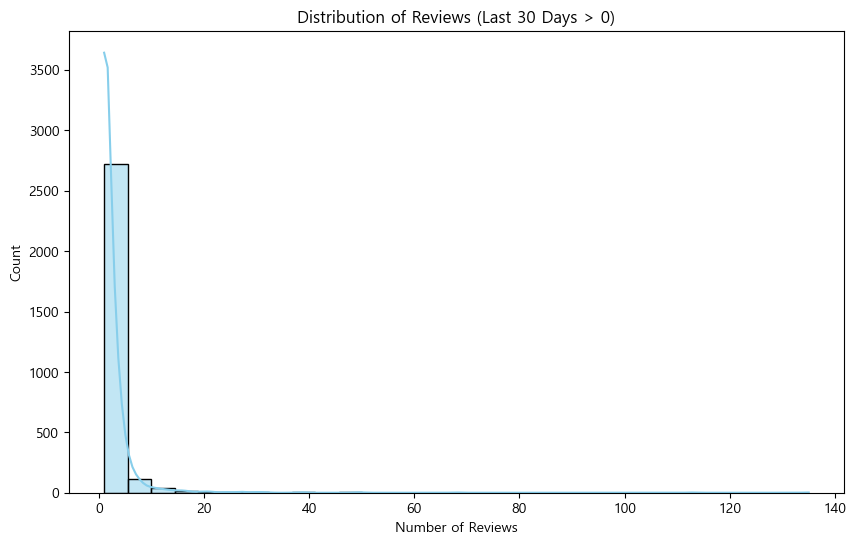

In [70]:
target_l30d = df.loc[df['number_of_reviews_l30d'] > 0, 'number_of_reviews_l30d']

plt.figure(figsize=(10, 6))
sns.histplot(target_l30d, kde=True, color='skyblue', bins=30)
plt.title('Distribution of Reviews (Last 30 Days > 0)')
plt.xlabel('Number of Reviews')
plt.ylabel('Count')
plt.show()

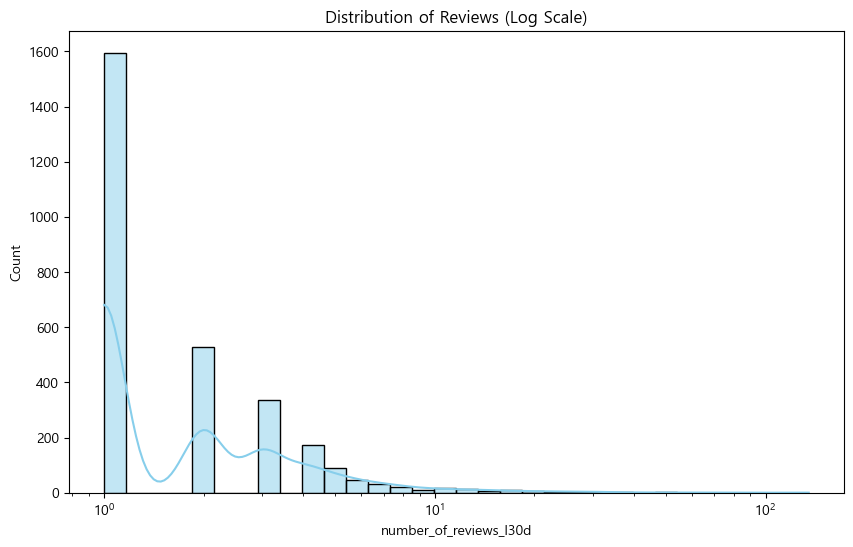

In [73]:
plt.figure(figsize=(10, 6))
sns.histplot(target_l30d, kde=True, color='skyblue', log_scale=True)
plt.title('Distribution of Reviews (Log Scale)')
plt.show()

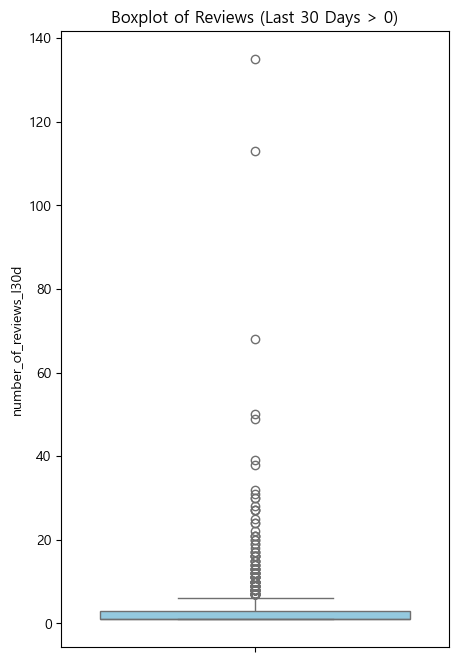

In [80]:
plt.figure(figsize=(5, 8))
sns.boxplot(target_l30d, color='skyblue')
plt.title('Boxplot of Reviews (Last 30 Days > 0)')
plt.show()